In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

#### Markov Decsion Process:
It is used to model decision-making in situations where outcomes are partly random and partly under an agent’s control. It consists of states, actions, transition probabilities (how actions move you between states), rewards (what you gain or lose), and a discount factor for future rewards. The “Markov” property means the next state depends only on the current state and action—not the full history.



An MDP is defined as a tuple:
[
(S, A, T, R, $\gamma$)
\]

- \( S \): set of states  
- \( A \): set of actions  
- \( T(s,a,s') = P(s' \mid s,a) \): transition probability  
- \( R(s,a) \): expected reward  
- \( $\gamma$ in [0,1] \): discount factor  


In [2]:
class MDP:
    def __init__(self, states, actions, T, R, gamma, start_states=None):
        self.states = states
        self.actions = actions
        self.T = T
        self.R = R
        self.gamma = gamma
        self.start_states = start_states or states

    def step(self, s, a):
        s_prime = list(self.T[s][a].keys())     #Gets the possible next statees from transistion dict
        probs    = list(self.T[s][a].values())  #Probability for the next states
        s_next   = np.random.choice(s_prime, p=probs)   #Picks the next state based on differet probabilities
        return s_next, self.R[s][a]

    def reset(self):
        return int(np.random.choice(self.start_states))   #Resets to a random start state

#### RiverSwim Environment
The **RiverSwim** environment is a classic reinforcement learning (RL) problem used to evaluate how well an agent can **explore** and plan for **long-term rewards**, rather than settling for short-term gains.

##### Scenario
Imagine a small fish (the agent) swimming in a river with a sequence of states:
- States are arranged linearly.
- Each state represents a position in the river.

**Goal**
- Reach the **final state** where a **large reward** (food) is located.
Challenge: A strong current pushes the fish **back toward the starting point**.

##### Actions
The agent (fish) has two possible actions:

##### Swim Left (Action 0)
- Easy and reliable  
- Usually sends the fish back to the **start**  
- Provides a **small reward**

##### Swim Right (Action 1)
- Difficult and **stochastic**  
- Outcomes:
  - May move forward or stay in place or pushed backward
- Eventually leads to the **high reward at the far right**

##### Environment Structure
- A chain of **6 states**: `0 → 5`
- Trade-off:
  - **Left** → safe, low reward  
  - **Right** → risky, high reward  

----

#### SixArms Environment
The **SixArms** environment tests an agent’s ability to balance exploitation abnd exploration. (Goal is to maximise rewards)


##### Scenario
- **State 0** acts as a central hub  
- There are **6 arms** (each different), each leading to a different state  


##### Arm Properties
Each arm has:
- A **probability of success** (often low)
- A **reward value**: Usually **Lower probability → Higher reward**

##### Challenge
The agent must learn to:
- Avoid sticking only to **easy, low-reward arms**
- Explore **rare but highly rewarding paths**
- Discover that **riskier actions can yield better long-term outcomes**

In [3]:
def make_riverswim():
    """
    RiverSwim MDP — Strehl & Littman (2008), Figure 1.
    Rewards at original paper scale: 5 (left end), 10000 (right end).
    """
    n = 6
    states  = list(range(n))
    actions = [0, 1]   # 0 = left, 1 = right

    T = {s: {a: {} for a in actions} for s in states}
    R = {s: {a: 0.0 for a in actions} for s in states}

    for s in states:
        # Left action (deterministic)
        if s == 0:
            T[s][0] = {0: 1.0}
            R[s][0] = 5.0           # FIX: was 0.0005
        else:
            T[s][0] = {s - 1: 1.0}

        # Right action (stochastic, fights the current)
        if s == 0:
            T[s][1] = {0: 0.6, 1: 0.4}
        elif s == n - 1:
            T[s][1] = {s: 0.7, s - 1: 0.3}
            R[s][1] = 10000.0       # FIX: was 1.0
        else:
            T[s][1] = {s - 1: 0.1, s: 0.6, s + 1: 0.3}

    return MDP(states, actions, T, R, gamma=0.95, start_states=[0, 1])


def make_sixarms():
    """
    SixArms MDP — Strehl & Littman (2008), Figure 1.
    Fixes:
      - arm_prob[0] = 1.0 (arm 0 always succeeds)
      - room_loops: only certain actions loop in a room (yield reward)
      - rewards at original scale (50, 133, ..., 6000), no /10000
    """
    states  = list(range(7))   # state 0 = hub, states 1-6 = rooms
    actions = list(range(6))

    arm_prob    = [1.0, 0.15, 0.10, 0.05, 0.03, 0.01]  # FIX: was [0.15,0.10,...]
    room_reward = [50,  133,  300,  800,  1660, 6000]   # FIX: no /10000

    # For room a+1, only actions in room_loops[a] loop (stay & reward)
    room_loops = [[0, 1, 2, 3, 5], [1], [2], [3], [4], [5]]

    T = {s: {a: {} for a in actions} for s in states}
    R = {s: {a: 0.0 for a in actions} for s in states}

    for a in actions:
        room = a + 1
        T[0][a] = {room: arm_prob[a], 0: 1 - arm_prob[a]}
        for other_a in actions:
            if other_a in room_loops[a]:   # FIX: loop structure
                T[room][other_a] = {room: 1.0}
                R[room][other_a] = room_reward[a]
            else:
                T[room][other_a] = {0: 1.0}

    return MDP(states, actions, T, R, gamma=0.95, start_states=[0])



#### Generic Value Iteration

This function implements **value iteration for an MDP**.

We are trying to compute:
$$
Q^*(s, a) = \mathbb{E}\left[ R + \gamma \max_{a'} Q^*(s', a') \right]
$$

At each iteration, the algorithm first derives state values from the current Q-function:
\[
V(s) = $\max_a$ Q(s,a)
\]

It then updates every state-action pair using the provided update rule:
```python
new_val = get_q_sa(s, a, V, R_hat, T_hat, n_visits)

In [4]:
def value_iteration(states, actions, R_hat, T_hat, n_visits,
                    gamma, get_q_sa, R_max=10000.0, threshold=0.01, max_iter=500):
    """
    Generic value iteration used by all agents.
    FIX: vmax = R_max/(1-gamma) instead of 1/(1-gamma).
    """
    vmax = R_max / (1.0 - gamma)    # FIX: must scale with R_max
    Q    = {s: {a: vmax for a in actions} for s in states}

    for _ in range(max_iter):
        V          = {s: max(Q[s][a] for a in actions) for s in states}
        max_change = 0.0
        new_Q      = {}

        for s in states:
            new_Q[s] = {}
            for a in actions:
                new_val    = get_q_sa(s, a, V, R_hat, T_hat, n_visits)
                new_val    = min(new_val, vmax)
                max_change = max(max_change, abs(new_val - Q[s][a]))
                new_Q[s][a] = new_val

        Q = new_Q
        if max_change < threshold:
            break

    return Q




##### Optimistic Transition Evaluation

This function computes an **optimistic estimate of a transition distribution**.
Given:
- Empirical transition model: $ \hat{T}(s' \mid s,a) $
- Value function: $ V(s') $
- Uncertainty radius: $ \epsilon $ (budget)

Most MBIE algorithms assume the environment maybe better than the current estimate as it encouirages exploration. This function basically slightly shifts probability mass toward high-value states and away from low value states making the transition actually look favourable.

If no optimism is allowed it computes the normal expected value $E_{t}[V]$.


##### Key Idea

The goal is to find the **most optimistic possible transition distribution** that is still consistent with the uncertainty bound.

Instead of brute-force optimization, it uses a known greedy solution:

- Move probability mass $\epsilon / 2$
  - from **lowest-value next states**
  - to the **highest-value next state**
- Then renormalize to maintain a valid probability distribution


In [5]:
def optimistic_transition_value(T_hat_sa, V, epsilon, states):
    """
    Greedy L1-shift: add epsilon/2 to highest-value state, remove from lowest.
    FIX: clamp T[s_high] to 1.0 immediately so probabilities stay valid.
    """
    if epsilon <= 0 or not T_hat_sa:
        return sum(T_hat_sa.get(s, 0.0) * V.get(s, 0.0) for s in states)

    T        = {s: T_hat_sa.get(s, 0.0) for s in states}
    by_value = sorted(states, key=lambda s: V.get(s, 0.0))
    s_high   = by_value[-1]

    T[s_high] = T[s_high] + epsilon / 2.0
    over      = max(T[s_high] - 1.0, 0.0)  # FIX: clamp and track overflow
    T[s_high] -= over
    to_remove  = epsilon / 2.0 - over       # FIX: reduce budget by overflow

    for s_low in by_value:
        if to_remove <= 1e-12:
            break
        take      = min(T[s_low], to_remove)
        T[s_low] -= take
        to_remove -= take

    total = sum(T.values())
    if total > 0:
        T = {s: v / total for s, v in T.items()}

    return sum(T[s] * V.get(s, 0.0) for s in states)


#### R-Max

The **R-Max** algorithm (Brafman & Tennenholtz, 2002) is a model-based reinforcement learning algorithm that achieves efficient exploration through **optimism under uncertainty**.

##### Core Idea

Every state-action pair $(s, a)$ is classified as **known** or **unknown**:
- A pair becomes **known** once it has been visited at least $m$ times
- **Unknown** pairs are assigned a fictitious reward $R_{\max}$ and a self-loop transition, making them look maximally attractive
- **Known** pairs use empirical estimates $\hat{R}(s,a)$ and $\hat{T}(s' \mid s,a)$ built from observed experience

This forces the agent to explore unknown regions before exploiting known ones.

##### Internal Model

At each update, R-Max maintains:
- Visit counts: $N(s, a)$
- Cumulative rewards → empirical reward: $\hat{R}(s,a) = \frac{\sum r}{N(s,a)}$
- Transition counts → empirical dynamics: $\hat{T}(s' \mid s,a)$

##### Policy Update

The policy is only recomputed when a pair $(s,a)$ transitions from unknown to known — this limits the number of costly value iteration calls. The optimistic MDP is solved using value iteration:

$$Q(s,a) = \begin{cases} \frac{R_{\max}}{1-\gamma} & \text{if } N(s,a) < m \\ \hat{R}(s,a) + \gamma \sum_{s'} \hat{T}(s' \mid s,a) \max_{a'} Q(s', a') & \text{otherwise} \end{cases}$$

In [6]:
class RMax:
    """
    R-Max algorithm (Brafman & Tennenholtz, 2002).

    Core idea (Section 6, Strehl & Littman 2008, footnote 12):
        Every state-action pair (s,a) is classified as "known" or "unknown".
        - Unknown (fewer than m visits): fictitious reward = R_max and
          fictitious transition = stay in s. This makes unknown pairs
          look maximally attractive, naturally driving exploration.
        - Known (at least m visits): use empirical estimates of R and T
          built from observed experience.

    At each update, R-Max solves its internal optimistic MDP via value
    iteration and follows the resulting optimal policy.

    Args:
        states    : list of states in the MDP
        actions   : list of actions in the MDP
        gamma     : discount factor (between 0 and 1)
        m         : visit threshold to declare (s,a) "known"
                    (m=16 for RiverSwim, m=6 for SixArms — Section 6)
        R_max     : fictitious reward for unknown pairs,
                    must be >= maximum possible reward in the true MDP
    """

    def __init__(self, states, actions, gamma, m, R_max):
        # Hyperparameters
        self.states   = states
        self.actions  = actions
        self.m        = m
        self.n_states  = len(states)
        self.n_actions = len(actions)
        self.gamma    = gamma
        self.R_max    = R_max

        # Current policy: action 0 everywhere by default
        # (updated as soon as a (s,a) pair becomes known)
        self.policy = np.zeros(self.n_states, dtype=int)

        # Visit counter per (s,a) pair — Section 3, "occupancy counts"
        self.N = np.zeros((self.n_states, self.n_actions))

        # Transition counter (s,a) -> s' — Section 3, "next-state counts"
        self.N_sas = np.zeros((self.n_states, self.n_actions, self.n_states))

        # Cumulative reward sum for (s,a)
        # used to compute R_hat(s,a) = R_sum / N
        self.R_sum = np.zeros((self.n_states, self.n_actions))

    def _is_known(self, s, a):
        """
        Return True if (s,a) has been visited at least m times.

        Direct definition from Section 4.3 (page 1317):
        "the set of known state-action pairs K is defined to be
        those (s,a) experienced at least m times"
        """
        si, ai = self.states.index(s), self.actions.index(a)
        return self.N[si, ai] >= self.m

    def _build_optimistic_model(self):
        """
        Build the internal optimistic MDP used by R-Max.

        For each (s,a):
            - If known   : use empirical estimates R_hat(s,a) and T_hat(s'|s,a)
            - If unknown : fictitious reward R_max + fictitious transition
                           (stay in s), making this pair maximally attractive

        This construction is the core of R-Max — it forces the agent
        to explore unknown regions before exploiting known ones.

        Returns:
            P_model : internal MDP transitions, shape (S, A, S)
            R_model : internal MDP rewards, shape (S, A)
        """
        S, A    = self.n_states, self.n_actions
        P_model = np.zeros((S, A, S))
        R_model = np.zeros((S, A))

        for s in range(S):
            for a in range(A):
                if self._is_known(self.states[s], self.actions[a]):
                    # Empirical mean reward estimate
                    R_model[s, a] = self.R_sum[s, a] / self.N[s, a]
                    # Empirical transition probability estimate
                    P_model[s, a] = self.N_sas[s, a] / self.N[s, a]
                else:
                    # Optimism: fictitious maximum reward
                    R_model[s, a]    = self.R_max
                    # Optimism: fictitious transition — agent stays in s
                    P_model[s, a, s] = 1.0

        return P_model, R_model

    def _update_policy(self):
        """
        Recompute the optimal policy by solving the internal optimistic MDP.

        Only called when a (s,a) pair has just transitioned from "unknown"
        to "known" — this limits the number of costly value iteration calls.
        """
        P_model, R_model = self._build_optimistic_model()

        # Convert NumPy arrays → dicts for the notebook's value_iteration
        R_hat = {s: {a: R_model[si, ai]
                    for ai, a in enumerate(self.actions)}
                for si, s in enumerate(self.states)}
        T_hat = {s: {a: {self.states[sp]: P_model[si, ai, sp]
                        for sp in range(self.n_states) if P_model[si, ai, sp] > 0}
                    for ai, a in enumerate(self.actions)}
                for si, s in enumerate(self.states)}
        n_vis = {s: {a: self.N[si, ai]
                    for ai, a in enumerate(self.actions)}
                for si, s in enumerate(self.states)}

        def get_q_sa(s, a, V, R_hat, T_hat, n_visits):
            si, ai = self.states.index(s), self.actions.index(a)
            if self.N[si, ai] < self.m:
                return self.R_max / (1 - self.gamma)   # fictitious max value
            r = R_hat[s][a]
            t = sum(p * V.get(sp, 0.0) for sp, p in T_hat[s][a].items())
            return r + self.gamma * t

        Q = value_iteration(self.states, self.actions,
                            R_hat, T_hat, n_vis, self.gamma, get_q_sa)

        for si, s in enumerate(self.states):
            best_ai = max(range(self.n_actions), key=lambda ai: Q[s][self.actions[ai]])
            self.policy[si] = best_ai

    def act(self, state):
        """
        Return the action to take from the given state.

        The agent simply follows the current policy — which is optimistic
        for unknown states and near-optimal for known ones.

        Args:
            state : current state of the agent

        Returns:
            action : integer between 0 and n_actions-1
        """
        si = self.states.index(state)
        return self.actions[self.policy[si]]

    def update(self, s, a, r, s_next):
        """
        Update the internal model after observing transition (s, a, r, s').

        Following Section 3 (page 1313): only the first m experiences of
        each (s,a) are stored. Beyond m, observations are ignored to
        preserve the theoretical guarantees of the algorithm.

        If (s,a) just reached exactly m visits, the policy is recomputed
        since this pair transitions from "unknown" to "known".

        Args:
            s      : current state
            a      : action taken
            r      : reward received
            s_next : next state observed
        """
        si   = self.states.index(s)
        ai   = self.actions.index(a)
        si_n = self.states.index(s_next)

        # Ignore visits beyond m (Section 3, "model size limit")
        if self.N[si, ai] < self.m:
            self.N[si, ai] += 1
            self.N_sas[si, ai, si_n] += 1
            self.R_sum[si, ai] += r

            # If (s,a) just reached m visits → it becomes "known"
            # → recompute the policy
            if self.N[si, ai] == self.m:
                self._update_policy()

#### MBIE (Model-Based Interval Estimation)
This class implements **MBIE (Model-Based Interval Estimation)**, a model-based reinforcement learning algorithm that learns from experience. It acts optimistically to encourage exploration.

It does three core things:
Estimate the model (rewards + transitions)
Add uncertainty bonuses (via ε terms)
Solve the MDP optimistically using value iteration

##### Estimation
The algorithm maintains:
- Visit counts: $ n(s,a) $
- Reward sums → empirical reward:  
  $ \hat{R}(s,a) $
- Transition counts → empirical dynamics:  
  $ \hat{T}(s' \mid s,a) $
These estimates improve as more samples are observed.

##### Q-value Update
If never visited:
$Q(s,a) = V_{\max} = \frac{1}{1 - \gamma}$

Otherwise:
- **Optimistic reward**  
$r^+ = \min(\hat{R}(s,a) + \epsilon_R,\ 1)$
- **Optimistic transitions**  
Shift probability mass toward high-value states within an $\epsilon_T$-budget.
- **Final value**  
$Q(s,a) = r^+ + \gamma \cdot \max_{T \approx \hat{T}} \sum_{s'} T(s') V(s')$


Essentially what we are doing is:
- Collect data (counts, rewards, transitions)  
- Estimate model ($\hat{R}, \hat{T}$)  
- Add optimism (bonuses + transition shift)  
- Run value iteration with this optimistic model  
- Act greedily: $\arg\max_a Q(s,a)$

In [7]:
class MBIE:
    """
    Model-Based Interval Estimation — Strehl & Littman (2008), Section 3.1.

    Fixes applied (supervisor feedback):
      - vmax = R_max / (1-gamma)           [was 1/(1-gamma)]
      - _eps_R returns R_max * A / sqrt(n) [was A / sqrt(n)]
      - removed min(r_upper, 1.0) clip     [was suppressing the bonus]
    """
    def __init__(self, states, actions, gamma,
                 A_param=0.3, B_param=0.0, R_max=10000.0, m=None):
        self.states  = states
        self.actions = actions
        self.gamma   = gamma
        self.A       = A_param
        self.B       = B_param
        self.R_max   = R_max                        # FIX: store R_max
        self.vmax    = R_max / (1.0 - gamma)        # FIX: R_max/(1-gamma)
        self.m       = m or 10000

        self.n    = {s: {a: 0   for a in actions} for s in states}
        self.Rsum = {s: {a: 0.0 for a in actions} for s in states}
        self.Tcnt = {s: {a: defaultdict(int) for a in actions} for s in states}
        self.Q    = {s: {a: self.vmax for a in actions} for s in states}

    def act(self, s):
        return max(self.actions, key=lambda a: self.Q[s][a])

    def update(self, s, a, r, s2):
        if self.n[s][a] >= self.m:
            return
        self.n[s][a] += 1
        self.Rsum[s][a] += r
        self.Tcnt[s][a][s2] += 1
        self._replan()

    def _R_hat(self, s, a):
        n = self.n[s][a]
        return self.Rsum[s][a] / n if n > 0 else 0.0

    def _T_hat(self, s, a):
        n = self.n[s][a]
        if n == 0:
            return {}
        return {sp: c / n for sp, c in self.Tcnt[s][a].items()}

    def _eps_R(self, s, a):
        n = self.n[s][a]
        return self.vmax if n == 0 else self.R_max * self.A / np.sqrt(n)  # FIX

    def _eps_T(self, s, a):
        n = self.n[s][a]
        return 2.0 if n == 0 else self.B / np.sqrt(n)

    def _get_q(self, s, a, V, R_hat, T_hat, n_visits):
        if n_visits[s][a] == 0:
            return self.vmax
        r_upper = self._R_hat(s, a) + self._eps_R(s, a)
        # FIX: removed min(r_upper, 1.0) — clipping killed the bonus
        t_val = optimistic_transition_value(
            self._T_hat(s, a), V, self._eps_T(s, a), self.states)
        return r_upper + self.gamma * t_val

    def _replan(self):
        self.Q = value_iteration(
            self.states, self.actions, None, None, self.n,
            self.gamma, self._get_q, R_max=self.R_max)


#### MBIE-EB
This class implements **MBIE-EB (Model-Based Interval Estimation with Exploration Bonus)**. Unlike MBIE, MBIE-EB does not modify transitions it only adds reward bonus

It maintains visit counts $n(s,a)$, cumulative rewards, and transition frequencies to compute empirical estimates $\hat{R}(s,a)$ and $\hat{T}(s' \mid s,a)$.

Q-values are updated using a modified Bellman equation that adds an explicit exploration bonus:

$$
Q(s,a) =
\hat{R}(s,a)
+ \frac{\beta}{\sqrt{n(s,a)}}
+ \gamma \sum_{s'} \hat{T}(s' \mid s,a) V(s')
$$

This bonus makes rarely visited state-action pairs look more valuable and encourages exploration.

The bonus shrinks as $n(s,a)$ increases, so exploration naturally decreases over time, it also repeatedly replans after each update as new data is collected.

In [8]:
class MBIE_EB:
    """
    MBIE with Exploration Bonus — Strehl & Littman (2008), Section 3.2, Eq. 8.

    Fixes applied (supervisor feedback):
      - vmax = R_max / (1-gamma)   [was 1/(1-gamma)]
      - beta = C * R_max           [was beta passed directly as small float]
    """
    def __init__(self, states, actions, gamma, C=0.4, R_max=10000.0, m=None):
        self.states  = states
        self.actions = actions
        self.gamma   = gamma
        self.R_max   = R_max
        self.beta    = C * R_max                 # FIX: beta = C * R_max
        self.vmax    = R_max / (1.0 - gamma)     # FIX: R_max/(1-gamma)
        self.m       = m or 10000

        self.n    = {s: {a: 0   for a in actions} for s in states}
        self.Rsum = {s: {a: 0.0 for a in actions} for s in states}
        self.Tcnt = {s: {a: defaultdict(int) for a in actions} for s in states}
        self.Q    = {s: {a: self.vmax for a in actions} for s in states}

    def act(self, s):
        return max(self.actions, key=lambda a: self.Q[s][a])

    def update(self, s, a, r, s2):
        if self.n[s][a] >= self.m:
            return
        self.n[s][a]    += 1
        self.Rsum[s][a] += r
        self.Tcnt[s][a][s2] += 1
        self._replan()

    def _get_q(self, s, a, V, R_hat, T_hat, n_visits):
        n = n_visits[s][a]
        if n == 0:
            return self.vmax
        R_hat_sa = self.Rsum[s][a] / n
        T_hat_sa = {sp: c / n for sp, c in self.Tcnt[s][a].items()}
        trans    = sum(p * V.get(sp, 0.0) for sp, p in T_hat_sa.items())
        bonus    = self.beta / np.sqrt(n)
        return R_hat_sa + self.gamma * trans + bonus

    def _replan(self):
        self.Q = value_iteration(
            self.states, self.actions, None, None, self.n,
            self.gamma, self._get_q, R_max=self.R_max)


## E3 — Explicit Explore or Exploit (Kearns & Singh, 2002)

Referenced in Strehl & Littman (2008) §2 and §6.

Maintains two separate policies:
- **Exploitation**: unknown (s,a) get reward 0 + self-loop → agent avoids them
- **Exploration**: unknown (s,a) get reward vmax + self-loop → agent seeks them

At each step, estimates P(exploitation policy hits unknown pair within H steps).
If > thresh → follow exploration policy. Otherwise exploit.

In [13]:
class E3:
    """
    Explicit Explore or Exploit — Kearns & Singh (2002).
    Paper parameters: m=16, thresh=0.01 (RiverSwim); m=4, thresh=0.09 (SixArms).
    """
    def __init__(self, states, actions, gamma,
                 m=16, thresh=0.01, H=None, n_escape_samples=30, R_max=10000.0):
        self.states  = states
        self.actions = actions
        self.gamma   = gamma
        self.m       = m
        self.thresh  = thresh
        self.R_max   = R_max
        self.vmax    = R_max / (1.0 - gamma)
        self.n_escape_samples = n_escape_samples
        if H is None:
            safe   = max(1.0 - gamma, 1e-9)
            self.H = max(20, int(np.ceil((1.0 / safe) * np.log(1.0 / safe))))
        else:
            self.H = H

        self.n         = {s: {a: 0   for a in actions} for s in states}
        self.Rsum      = {s: {a: 0.0 for a in actions} for s in states}
        self.Tcnt      = {s: {a: defaultdict(int) for a in actions} for s in states}
        self.Q_exploit = {s: {a: self.vmax for a in actions} for s in states}
        self.Q_explore = {s: {a: self.vmax for a in actions} for s in states}

    def _is_known(self, s, a):
        return self.n[s][a] >= self.m

    def _T_hat(self, s, a):
        n = self.n[s][a]
        if n == 0:
            return {}
        return {sp: c / n for sp, c in self.Tcnt[s][a].items()}

    def _get_q_exploit(self, s, a, V, _R, _T, _n):
        # Unknown pairs: reward 0, self-loop → Q = 0 (unattractive)
        if not self._is_known(s, a):
            return 0.0
        R  = self.Rsum[s][a] / self.n[s][a]
        ev = sum(p * V.get(sp, 0.0) for sp, p in self._T_hat(s, a).items())
        return R + self.gamma * ev

    def _get_q_explore(self, s, a, V, _R, _T, _n):
        # Unknown pairs: reward vmax, self-loop → Q = vmax (very attractive)
        if not self._is_known(s, a):
            return self.vmax
        R  = self.Rsum[s][a] / self.n[s][a]
        ev = sum(p * V.get(sp, 0.0) for sp, p in self._T_hat(s, a).items())
        return R + self.gamma * ev

    def _replan(self):
        self.Q_exploit = value_iteration(
            self.states, self.actions, None, None, self.n,
            self.gamma, self._get_q_exploit, R_max=self.R_max)
        self.Q_explore = value_iteration(
            self.states, self.actions, None, None, self.n,
            self.gamma, self._get_q_explore, R_max=self.R_max)

    def _escape_probability(self, s):
        """Monte-Carlo: P(exploitation policy reaches unknown (s,a) within H steps)."""
        count = 0
        for _ in range(self.n_escape_samples):
            state   = s
            escaped = False
            for _ in range(self.H):
                a = max(self.actions, key=lambda a: self.Q_explore[state][a])
                if not self._is_known(state, a):
                    escaped = True
                    break
                T = self._T_hat(state, a)
                if not T:
                    escaped = True
                    break
                state = int(np.random.choice(list(T.keys()), p=list(T.values())))
            if escaped:
                count += 1
        return count / self.n_escape_samples

    def act(self, s):
        if self._escape_probability(s) > self.thresh:
            return max(self.actions, key=lambda a: self.Q_explore[s][a])
        return max(self.actions, key=lambda a: self.Q_exploit[s][a])

    def update(self, s, a, r, s2):
        if self.n[s][a] >= self.m:
            return
        self.n[s][a]       += 1
        self.Rsum[s][a]    += r
        self.Tcnt[s][a][s2] += 1
        self._replan()


#### Training and evaluation


The `run` function simulates a single episode of interaction between an agent and an MDP for `n_steps`. At each step, the agent selects an action, observes the resulting transition and reward, updates its internal model, and accumulates total reward over time. It returns the full learning curve of cumulative reward.

The `run_many` function repeats this process across multiple random seeds and initializations to reduce variance. It then aggregates the results by computing the mean and standard deviation of cumulative rewards at each timestep, providing a more stable estimate of the agent’s learning performance.

In [14]:
def run(mdp, agent, n_steps=5000, seed=42, debug=False):
    """
    Run one episode. Returns full cumulative reward curve (length n_steps).
    Set debug=True to print state/action/reward trace every 100 steps.
    """
    np.random.seed(seed)
    s     = mdp.reset()
    total = 0.0
    r_ema = 0.0
    cumulative = np.zeros(n_steps)

    for t in range(n_steps):
        a       = agent.act(s)
        s2, r   = mdp.step(s, a)
        agent.update(s, a, r, s2)
        total  += r
        r_ema   = r_ema * 0.99 + r * 0.01
        cumulative[t] = total
        if debug and t % 100 == 0:
            print(f"  t={t:4d}  s={s}  a={a}  r_ema={r_ema:.1f}")
        s = s2

    return cumulative   # FIX: return full curve, not just final total


def run_many(mdp_fn, agent_fn, n_steps=5000, n_trials=10):
    """Average over multiple seeds. Returns (mean curve, std curve)."""
    curves = np.array([
        run(mdp_fn(), agent_fn(), n_steps, seed=i)
        for i in range(n_trials)
    ])
    return curves.mean(axis=0), curves.std(axis=0)


#### River swim experiment comparision
This code runs and visualizes reinforcement learning experiments on the **RiverSwim** environment by comparing different model-based algorithms.

It first sets a fixed random seed for reproducibility, defines the environment size and number of trials, and evaluates agents (such as MBIE and MBIE-EB) using `run_many`. This function computes the mean and standard deviation of cumulative reward over multiple runs to reduce variance.

The results are then stored and visualized: a bar chart comparing final cumulative performance across algorithms.

Running RiverSwim experiments...
Done!


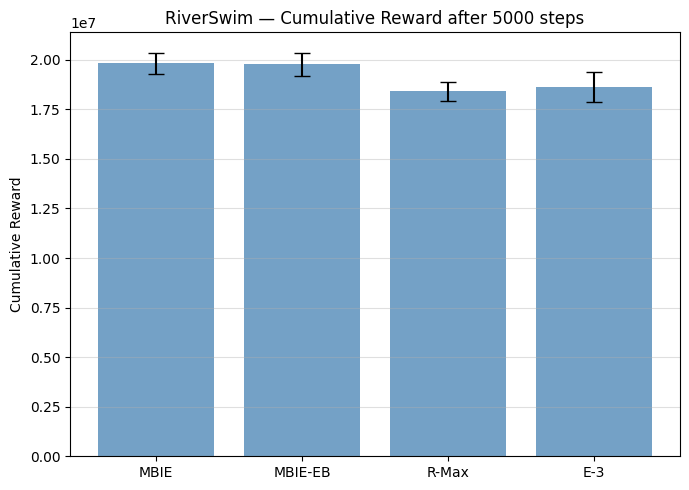

In [17]:
np.random.seed(0)
N, T_TRIALS = 5000, 10

S6, A2 = list(range(6)), [0, 1]
R_MAX_RS = 10000.0

results_rs = {}
print("Running RiverSwim experiments...")

mean, std = run_many(make_riverswim,
    lambda: MBIE(S6, A2, 0.95, A_param=0.3, B_param=0.0, R_max=R_MAX_RS), N, T_TRIALS)
results_rs['MBIE'] = (mean, std)

mean, std = run_many(make_riverswim,
    lambda: MBIE_EB(S6, A2, 0.95, C=0.4, R_max=R_MAX_RS), N, T_TRIALS)
results_rs['MBIE-EB'] = (mean, std)

mean, std = run_many(make_riverswim,
    lambda: RMax(S6, A2, 0.95, m=16, R_max=R_MAX_RS), N, T_TRIALS)
results_rs['R-Max'] = (mean, std)

mean, std = run_many(make_riverswim,
    lambda: E3(S6, A2, 0.95, m=16, thresh=0.01, R_max=R_MAX_RS), N, T_TRIALS)
results_rs['E-3'] = (mean, std)

print("Done!")

fig, ax = plt.subplots(figsize=(7, 5))
names = list(results_rs.keys())
means = [results_rs[k][0][-1] for k in names]   # FIX: [-1] for final value of curve
stds  = [results_rs[k][1][-1] for k in names]
ax.bar(names, means, yerr=stds, capsize=6, color='steelblue', alpha=0.75)
ax.set_title('RiverSwim — Cumulative Reward after 5000 steps')
ax.set_ylabel('Cumulative Reward')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()


#### SixArms experiment comparision
This code runs reinforcement learning experiments on the **SixArms environment**, comparing different model-based algorithms.

It defines a 7-state environment with 6 actions, then evaluates each agent using `run_many`, which averages performance over multiple trials to ensure statistical stability.

The results are stored and visualized using a bar chart showing final cumulative reward.

Running SixArms experiments...
Done!


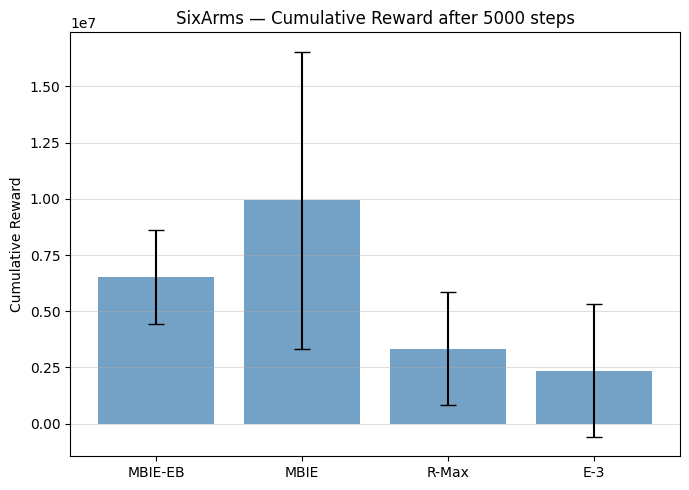

In [18]:
S7, A6 = list(range(7)), list(range(6))
R_MAX_SA = 6000.0

results_sa = {}
print("Running SixArms experiments...")

mean, std = run_many(make_sixarms,
    lambda: MBIE_EB(S7, A6, 0.95, C=0.8, R_max=R_MAX_SA), N, T_TRIALS)
results_sa['MBIE-EB'] = (mean, std)

mean, std = run_many(make_sixarms,
    lambda: MBIE(S7, A6, 0.95, A_param=0.3, B_param=0.08, R_max=R_MAX_SA), N, T_TRIALS)
results_sa['MBIE'] = (mean, std)

mean, std = run_many(make_sixarms,
    lambda: RMax(S7, A6, 0.95, m=6, R_max=R_MAX_SA), N, T_TRIALS)
results_sa['R-Max'] = (mean, std)

mean, std = run_many(make_sixarms,
    lambda: E3(S7, A6, 0.95, m=4, thresh=0.09, R_max=R_MAX_SA), N, T_TRIALS)
results_sa['E-3'] = (mean, std)

print("Done!")

fig, ax = plt.subplots(figsize=(7, 5))
names = list(results_sa.keys())
means = [results_sa[k][0][-1] for k in names]
stds  = [results_sa[k][1][-1] for k in names]
ax.bar(names, means, yerr=stds, capsize=6, color='steelblue', alpha=0.75)
ax.set_title('SixArms — Cumulative Reward after 5000 steps')
ax.set_ylabel('Cumulative Reward')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()
